In [41]:
import sys
sys.path.append('../lib/')
import numpy as np
import healpy as hp
import pysm3
import pysm3.units as u
import pymaster as nmt
import matplotlib.pyplot as plt
from tqdm import trange
import basicfunc as func
import simu_lib as sim

In [42]:
# PySM model to consider, d#s#

dust_type = 10
sync_type = 5
nside_pysm = 512

nside = 64
Npix = hp.nside2npix(nside)
lmax = 2*nside-1
Nlbin = 10

# Reference frequencies in GHz

nu0d = 402
nu0s = 40

In [43]:
# Compute dust moments maps

GAL070 = hp.read_map('HFI_Mask_GalPlane-apo0_2048_R2.00.fits', field=4)
GAL070 = hp.ud_grade(GAL070, nside_pysm)
GAL070[GAL070<0.5], GAL070[GAL070>0.5] = 0, 1

GAL070_dg = hp.ud_grade(np.float64(GAL070), nside)
GAL070_dg[GAL070_dg<0.5], GAL070_dg[GAL070_dg>0.5] = 0, 1

sky = pysm3.Sky(nside_pysm, preset_strings=[f'd{dust_type}'], output_unit=u.uK_CMB)
dust = sky.components[0]
beta_map = dust.mbb_index.value
T_map = dust.mbb_temperature.value

if dust_type == 12:
    A_map = dust.layers.value
    A_complex = (A_map[:,1] + 1j * A_map[:,2]) * func.unit_conversion(353, input_unit='uK_RJ', output_unit='uK_CMB') / func.mbb_uK(353, beta_map, 1/T_map, nu0=nu0d)
else:
    A_map = sky.get_emission(nu0d * u.GHz).value
    A_complex = np.array([A_map[1] + 1j * A_map[2]])
    beta_map = np.array([beta_map])
    T_map = np.array([T_map])

beta_bar = np.average(beta_map[0][GAL070==1], weights=A_complex[0][GAL070==1]).real
T_bar = 1 / np.average(1/T_map[0][GAL070==1], weights=A_complex[0][GAL070==1]).real

w2b = np.sum(A_complex * (beta_map-beta_bar)**2, axis=0)

In [44]:
beta_bar, T_bar

(np.float64(1.6199264222523038), np.float64(19.071164138428212))

In [64]:
w2b_IQU = np.array([np.zeros_like(w2b.real), w2b.real, w2b.imag])
w2b_IQU = hp.smoothing(w2b_IQU, np.radians(3))
w2b_B = hp.alm2map(hp.map2alm(w2b_IQU)[2], nside=nside_pysm)

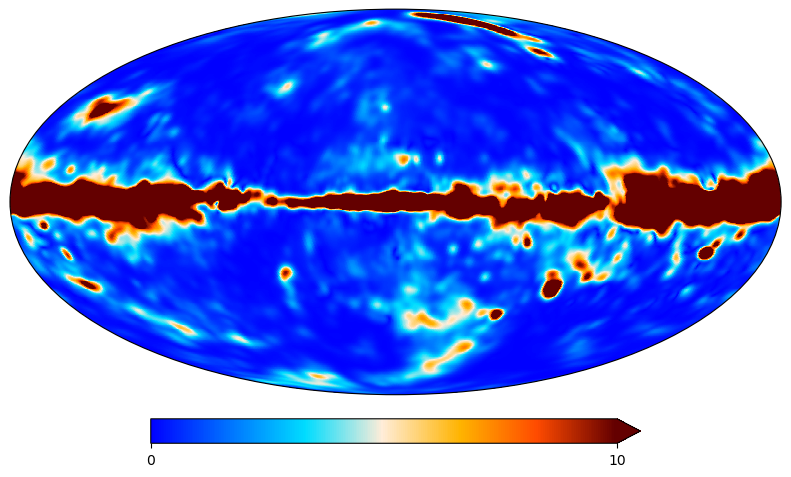

In [65]:
hp.projview(np.sqrt(np.sum(w2b_IQU[1:]**2, axis=0)), min=0, max=10, cmap='planck')
plt.show()

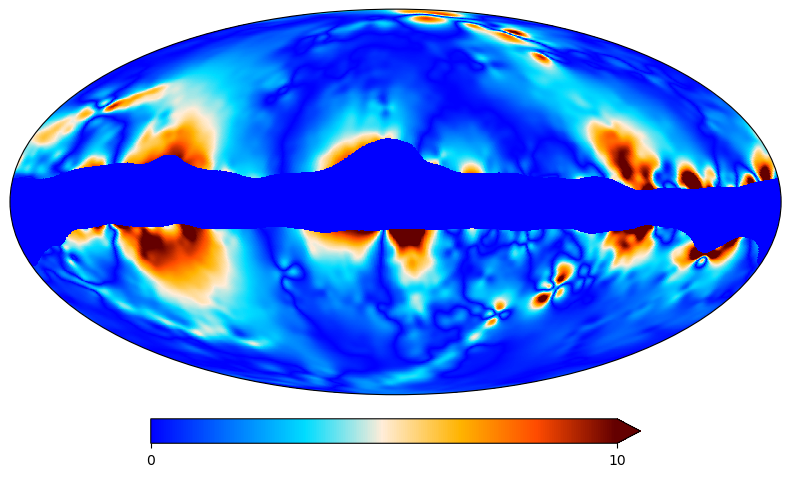

In [66]:
hp.projview(np.abs(w2b_B * GAL070), min=0, max=10, cmap='planck')
plt.show()

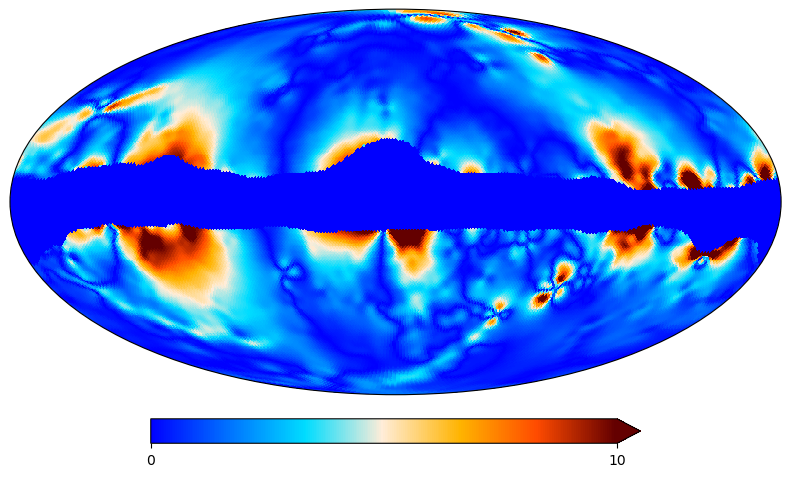

In [67]:
w2b_dg = hp.ud_grade(w2b_B, nside)
hp.projview(np.abs(w2b_dg*GAL070_dg), min=0, max=10, cmap='planck')
plt.show()

In [70]:
w2b_dg[GAL070_dg==0] = np.max(w2b_dg)

fsky = 0.62
threshold = np.quantile(np.abs(w2b_dg), fsky)

mask = np.ones(Npix)
mask[np.abs(w2b_dg) > threshold] = 0

In [71]:
threshold

np.float64(3.5825358233748816)

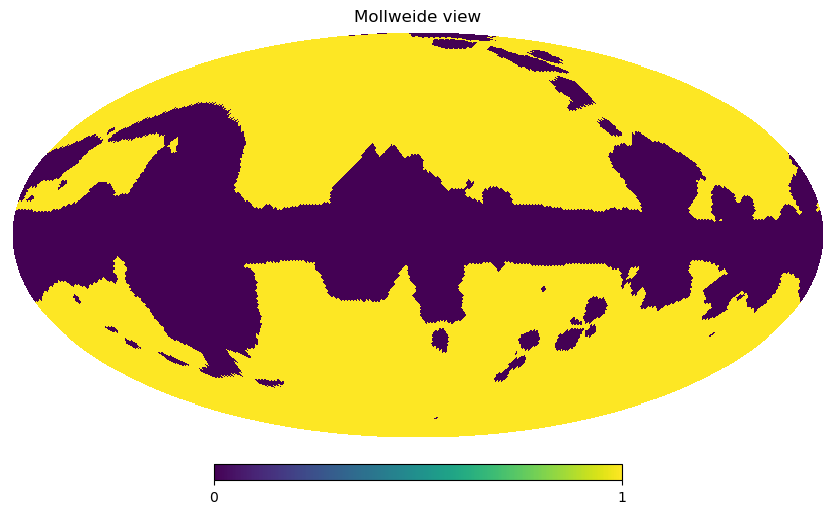

In [72]:
hp.mollview(mask)
plt.show()

In [73]:
np.mean(mask**2)

np.float64(0.6199951171875)

In [74]:
#fsky = 0.6

#mask2 = hp.smoothing(mask*GAL070_dg, np.radians(10))
#mask2 = mask * GAL070_dg
#threshold = np.quantile(mask2, 1-fsky)
#mask2[mask2<threshold], mask2[mask2>threshold] = 0, 1

mask2 = np.copy(mask)

alm_mask = hp.map2alm(mask2)
lmax_in = 3*nside-1
lmax_out = int(180 / 20)

alm_mask_lp = np.zeros_like(alm_mask, dtype=complex)

for m in range(lmax_out+1):
    idx_1 = hp.sphtfunc.Alm.getidx(lmax_in, m, m)
    idx_2 = hp.sphtfunc.Alm.getidx(lmax_in, lmax_out, m)

    alm_mask_lp[idx_1:idx_2+1] = alm_mask[idx_1:idx_2+1]

mask2_lp = hp.alm2map(alm_mask_lp, nside=nside)
mask2_lp[mask2_lp<0.5], mask2_lp[mask2_lp>0.5] = 0, 1

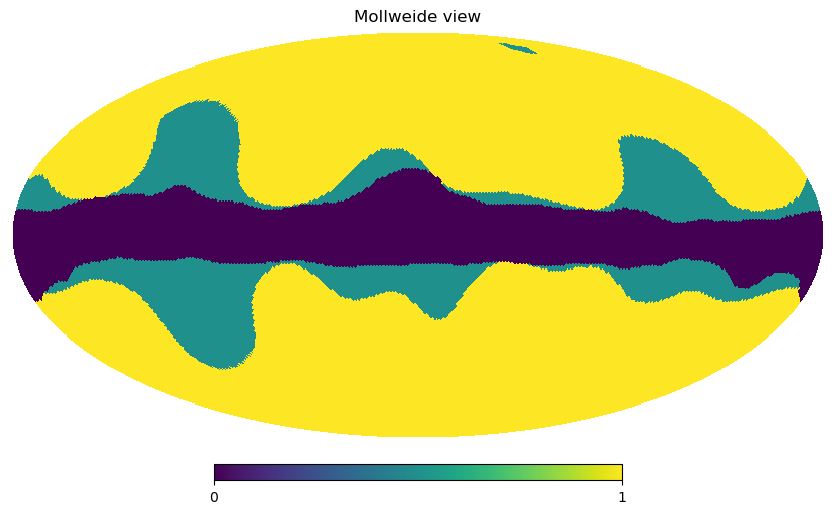

In [75]:
masks = np.ones(Npix)
masks[mask2_lp==0], masks[GAL070_dg==0] = 0.5, 0
hp.mollview(masks)
plt.show()

In [76]:
np.mean(mask2_lp**2)

np.float64(0.6322835286458334)

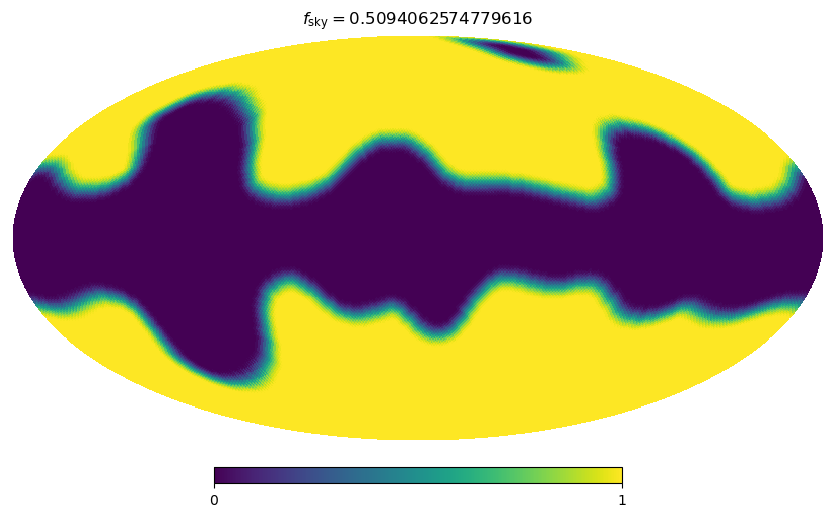

In [77]:
mask_apod = nmt.mask_apodization(mask2_lp, aposize=10, apotype='C2')
hp.mollview(mask_apod, title=r'$f_{\rm sky} = %s$' % np.mean(mask_apod**2))
plt.show()

In [78]:
# Test on CMB only

N = 100
lmax = 2*nside-1
Nlbin = 10

b = nmt.NmtBin.from_lmax_linear(lmax, nlb=Nlbin, is_Dell=True)
leff = b.get_effective_ells()
Nbins = len(leff)

Cl_CMB = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')
Dl_CMB = b.bin_cell(Cl_CMB[2, :lmax+1])
Dl_BB = np.zeros((N, Nbins))

f = nmt.NmtField(mask_apod, None, spin=2, lmax=lmax, purify_b=True)
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(f, f, b)

for i in trange(N):
    cmb = hp.synfast(Cl_CMB, nside, new=True)[1:]

    f = nmt.NmtField(mask_apod, cmb, purify_b=True)
    Cl_coupled = nmt.compute_coupled_cell(f, f)
    Dl_BB[i] = w.decouple_cell(Cl_coupled)[3]

100%|██████████| 100/100 [00:08<00:00, 11.38it/s]


In [79]:
# Planck 60% on CMB only

GAL060 = hp.read_map('mask_fsky0.6_nside64_aposcale10.npy')

N = 100
lmax = 2*nside-1
Nlbin = 10

b = nmt.NmtBin.from_lmax_linear(lmax, nlb=Nlbin, is_Dell=True)
leff = b.get_effective_ells()
Nbins = len(leff)

Cl_CMB = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')
Dl_CMB = b.bin_cell(Cl_CMB[2, :lmax+1])
Dl_BB_GAL060 = np.zeros((N, Nbins))

f = nmt.NmtField(GAL060, None, spin=2, lmax=lmax, purify_b=True)
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(f, f, b)

for i in trange(N):
    cmb = hp.synfast(Cl_CMB, nside, new=True)[1:]

    f = nmt.NmtField(GAL060, cmb, purify_b=True)
    Cl_coupled = nmt.compute_coupled_cell(f, f)
    Dl_BB_GAL060[i] = w.decouple_cell(Cl_coupled)[3]

100%|██████████| 100/100 [00:08<00:00, 11.40it/s]


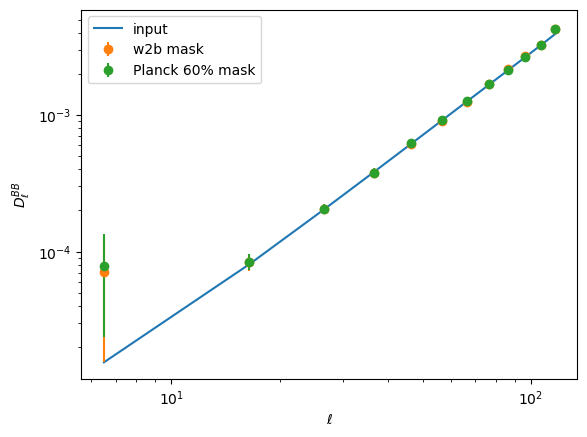

In [80]:
plt.plot(leff, Dl_CMB, label='input')
plt.errorbar(leff, np.mean(Dl_BB, axis=0), yerr=np.std(Dl_BB, axis=0), fmt='o', label='w2b mask')
plt.errorbar(leff, np.mean(Dl_BB_GAL060, axis=0), yerr=np.std(Dl_BB, axis=0), fmt='o', label='Planck 60% mask')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{BB}$')
plt.legend()

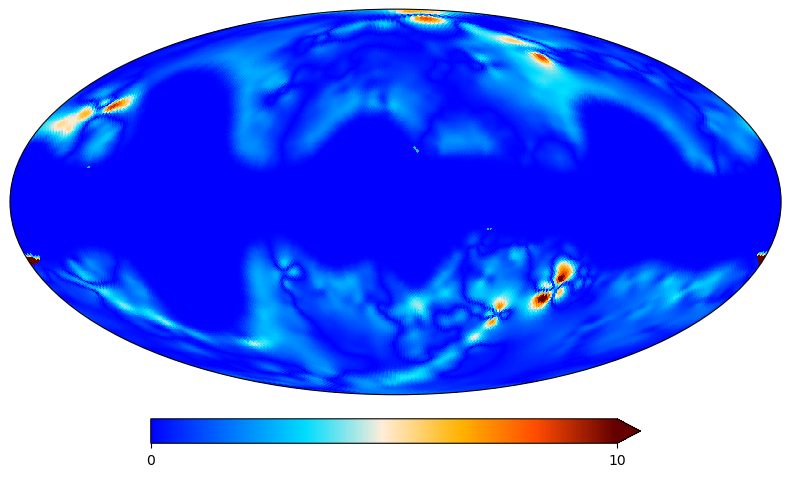

In [81]:
hp.projview(np.abs(w2b_dg*mask_apod), min=0, max=10, cmap='planck')
plt.show()